# vehicle analysis

In [1]:
import pandas as pd
import numpy as np
import ast
import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython.display import display
import scipy

In [2]:
df = pd.read_csv(r"C:\Users\prade\OneDrive\Documents\Code\TransportFever2\Data\raw\vehicle.csv")
df['cargo_type'] = df['cargo_type'].apply(lambda x: ast.literal_eval(x))
df

,name,yearFrom,yearTo,lifespan,power,tractiveEffort,topSpeed,weight,carrier,cargo_type,loadSpeed,vehicle_type
0,aboag_v2,1922,1972,21915,35.0,8.0,9.720000,5.0,ROAD,{'PASSENGERS': 44},1.5,bus
1,benz_o6600_v2,1954,2000,21915,107.0,12.0,19.440001,9.0,ROAD,{'PASSENGERS': 56},2.0,bus
2,berkhof_duvedec_v2,1986,0,21915,180.0,30.0,25.000000,15.0,ROAD,{'PASSENGERS': 92},5.0,bus
3,ecitaro_v2,2019,0,25568,150.0,30.0,19.440001,14.0,ROAD,{'PASSENGERS': 68},5.0,bus
4,et13_v2,1905,1956,21915,20.0,6.0,6.940000,4.0,ROAD,{'PASSENGERS': 32},1.5,bus
...,...,...,...,...,...,...,...,...,...,...,...,...
336,stake_car_1952,1950,0,36525,NaN,NaN,33.333333,15.0,RAIL,"{'LOGS': 72, 'STEEL': 72, 'PLANKS': 72, 'CONST...",3.0,waggon
337,streamlined_santa_fe_v2,1935,2000,25568,NaN,NaN,41.669998,30.0,RAIL,{'PASSENGERS': 72},1.0,waggon
338,tankcar_1860,1850,1950,29220,NaN,NaN,13.888889,10.0,RAIL,"{'CRUDE': 28, 'OIL': 28, 'FUEL': 28}",1.0,waggon
339,tankcar_1899,1900,2000,32873,NaN,NaN,22.222222,15.0,RAIL,"{'CRUDE': 48, 'OIL': 48, 'FUEL': 48}",2.0,waggon


In [3]:
df['topSpeed'] = df['topSpeed']*3.6 # to km/h

In [4]:
df['capacity'] = df['cargo_type'].apply(lambda x: np.mean([v for v in x.values() if v is not None]))

c:\Users\prade\miniconda3\envs\dev_env\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\prade\miniconda3\envs\dev_env\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [5]:
df['cargo_type'] = df['cargo_type'].apply(lambda x: [v for v in x.keys() if v is not None])

In [6]:
df['yearTo'].loc[df['yearTo']==0] = float('inf') 

C:\Users\prade\AppData\Local\Temp\ipykernel_3432\1286542283.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['yearTo'].loc[df['yearTo']==0] = float('inf')
C:\Users\prade\AppData\Local\Temp\ipykernel_3432\1286542283.py:1: SettingWithCop

In [7]:
print(list(df.vehicle_type.unique()))
print(df.columns)

['bus', 'plane', 'ship', 'train', 'tram', 'truck', 'waggon']
Index(['name', 'yearFrom', 'yearTo', 'lifespan', 'power', 'tractiveEffort',
       'topSpeed', 'weight', 'carrier', 'cargo_type', 'loadSpeed',
       'vehicle_type', 'capacity'],
      dtype='object')


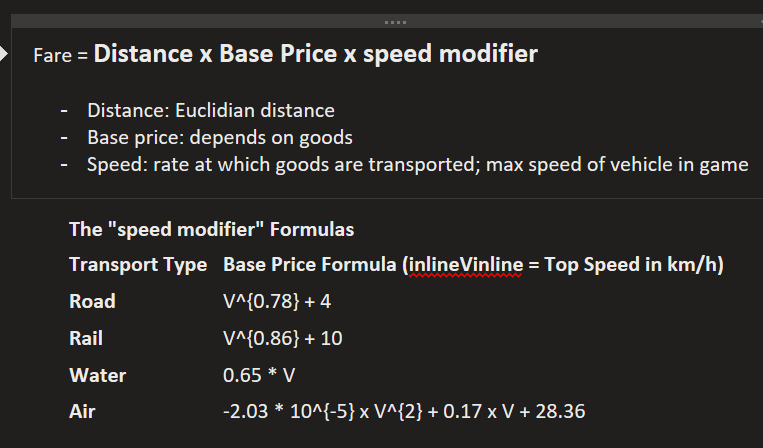

In [8]:
df['baseXspeedmod'] = None

mask = (df['carrier']=='ROAD')
df.loc[mask,'baseXspeedmod'] = df.loc[mask, 'topSpeed'].apply(lambda x: (x**0.78)+4)

mask = (df['carrier']=='RAIL')
df.loc[mask,'baseXspeedmod'] = df.loc[mask, 'topSpeed'].apply(lambda x: (x**0.86)+10)

mask = (df['carrier']=='TRAM')
df.loc[mask,'baseXspeedmod'] = df.loc[mask, 'topSpeed'].apply(lambda x: (x**0.5))

mask = (df['carrier']=='WATER')
df.loc[mask,'baseXspeedmod'] = df.loc[mask, 'topSpeed'].apply(lambda x: x*0.65)

mask = (df['carrier']=='AIR')
df.loc[mask,'baseXspeedmod'] = df.loc[mask, 'topSpeed'].apply(lambda x: (-2.03e-5)*(x**2)+(x*0.17)+28.36)

df['baseXspeedmod'] = df['baseXspeedmod'].apply(lambda x: round(x*1.375, 2))

## finding price

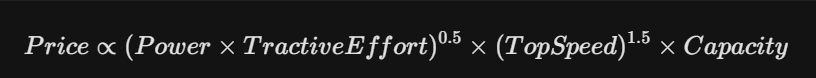

In [9]:
df['price'] = ((df['power']*df['tractiveEffort'])**0.5)*((df['topSpeed'])**1.5)*(df['capacity'])

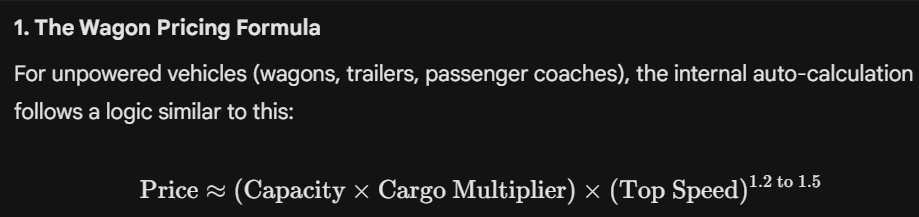

In [10]:
mask = pd.isna(df['price'])
df.loc[mask, 'price'] = df[mask].apply(lambda x: x['capacity'] * (x['topSpeed'])**1.5, axis=1)

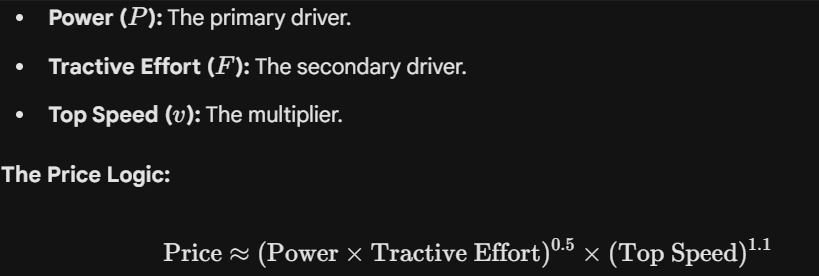

In [11]:
mask = pd.isna(df['price'])
df.loc[mask, 'price'] = df[mask].apply(lambda x: ((x['power']*x['tractiveEffort'])**0.5)*((x['topSpeed'])**1.5), axis=1)

In [12]:
df['price'] = df['price'].apply(lambda x: round(x))

## plot optimal distance per capacity

In [13]:
def plot_efficiency_per_capacity(yearFrom, yearTo, vehicle_types):
    temp = df.loc[(df['yearFrom'].between(yearFrom, yearTo,inclusive='both'))]
    for vehicle_type in vehicle_types:
        temp_1 = temp.loc[temp['vehicle_type']==vehicle_type]
        
    

## maintenance per capacity

In [14]:
df['maintenancePc'] = df['price']/(6*df['capacity'])

mask = pd.isna(df['maintenancePc'])
df.loc[mask, 'maintenancePc'] = df.loc[mask, 'price'].apply(lambda x: x)

df['maintenancePc'] = df['maintenancePc'].apply(lambda x: round(x,2))

## break even distance

In [15]:
df['breakeven_dist'] = df['maintenancePc']/df['baseXspeedmod']
df['breakeven_dist'] = df['breakeven_dist'].apply(lambda x: round(x,2))

In [18]:
df.groupby(['vehicle_type']).agg({'breakeven_dist':'mean'}).round(2).reset_index().sort_values(by=['breakeven_dist'])

,vehicle_type,breakeven_dist
2,ship,1.06
6,waggon,1.88
1,plane,14.26
0,bus,80.60
5,truck,125.95
4,tram,496.20
3,train,6507.11


(array([3., 1., 2., 2., 3., 1., 3., 3., 7., 4.]),
 array([ 3.79,  5.52,  7.25,  8.98, 10.71, 12.44, 14.17, 15.9 , 17.63,
        19.36, 21.09]),
 <BarContainer object of 10 artists>)

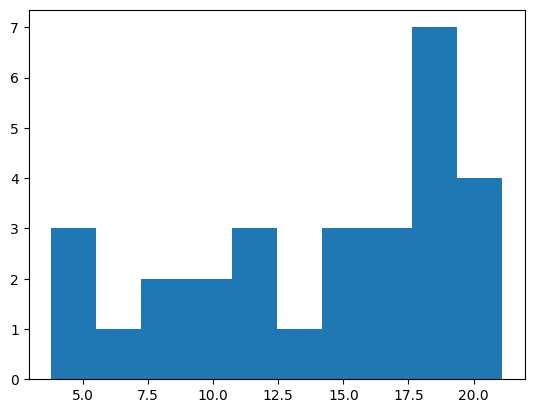

In [21]:
plt.hist(df['breakeven_dist'].loc[df['vehicle_type']=='plane'])

In [16]:
test = df.groupby(['yearFrom','vehicle_type']).agg({'breakeven_dist':'mean'}).round(2).reset_index()
test = test.sort_values(by=['yearFrom','breakeven_dist'], ascending=[True,True])
test

,yearFrom,vehicle_type,breakeven_dist
1,1850,ship,0.89
5,1850,waggon,1.07
0,1850,bus,1.46
4,1850,truck,2.31
3,1850,tram,4.53
...,...,...,...
196,2018,tram,2146.54
195,2018,train,31068.72
197,2019,bus,151.20
198,2020,truck,201.61
